In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install seaborn scipy -q

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Cs:Go_Project')


Diretório de trabalho: /content/drive/MyDrive/Cs:Go_Project
Resultados em:         /content/drive/MyDrive/Cs:Go_Project/resultados

[1/4] Carregando dados...
  Total: 12000 players  |  Cheaters: 2000  |  Legítimos: 10000
  Razão desbalanceamento: 1:5  →  class_weight={0: 1.0, 1: 5.0}
  Shape X: (12000, 30, 192, 5)

[2/4] Gerando Figura 1 — Visão Geral...


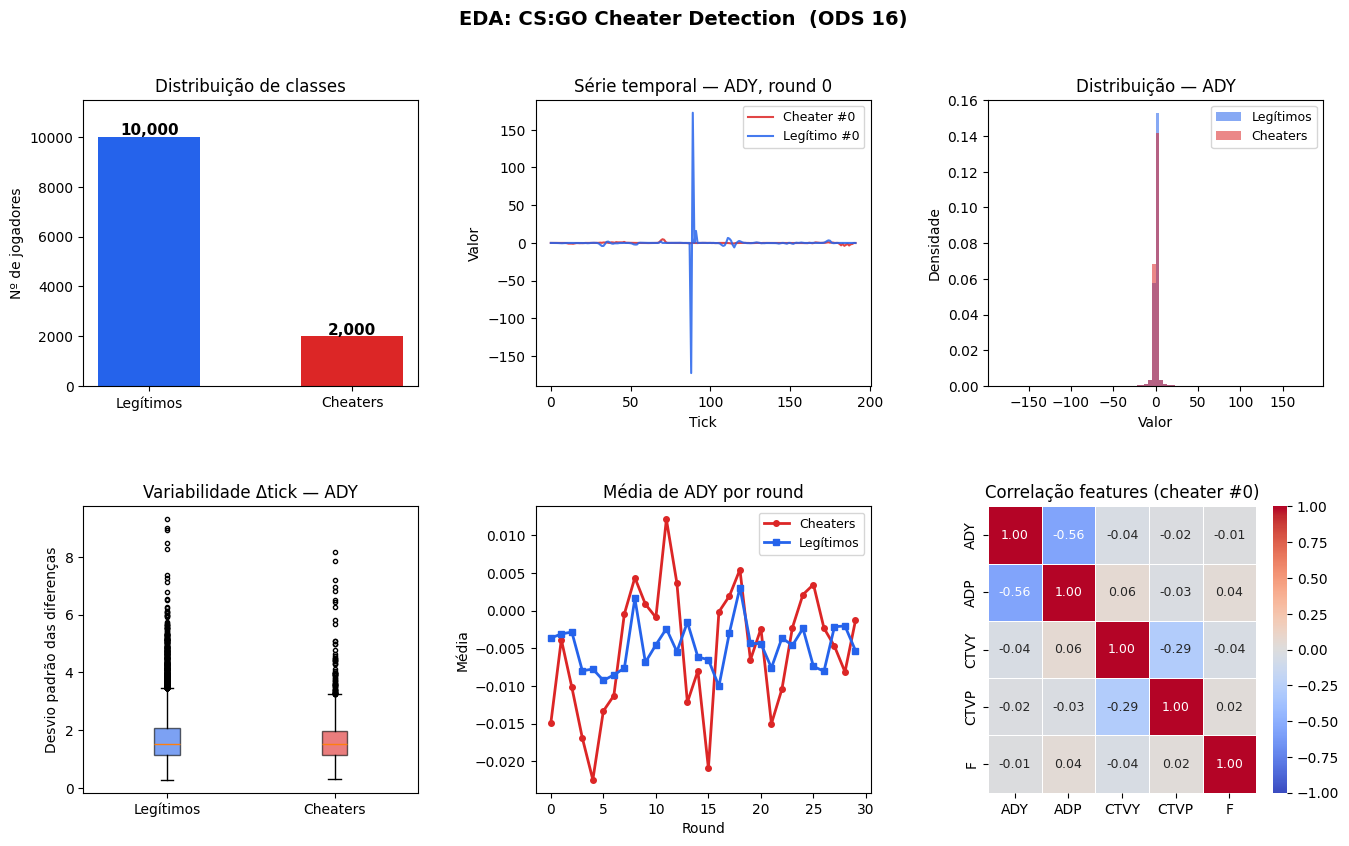

[3a/4] Gerando Figura 2 — Distribuições por feature...


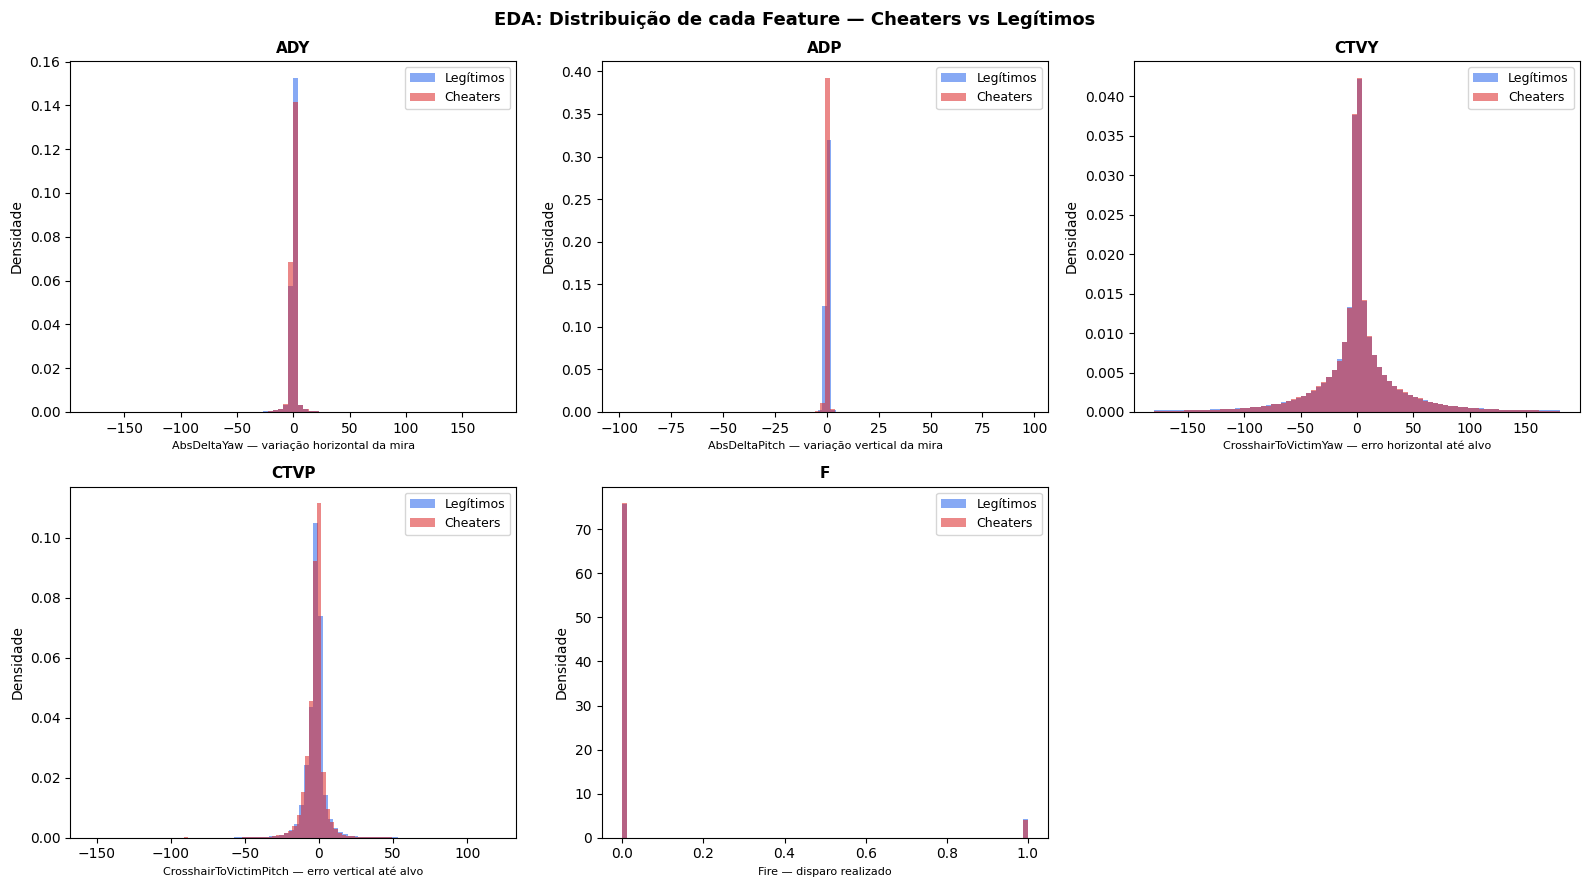

[3b/4] Gerando Figura 3 — Variabilidade por feature...


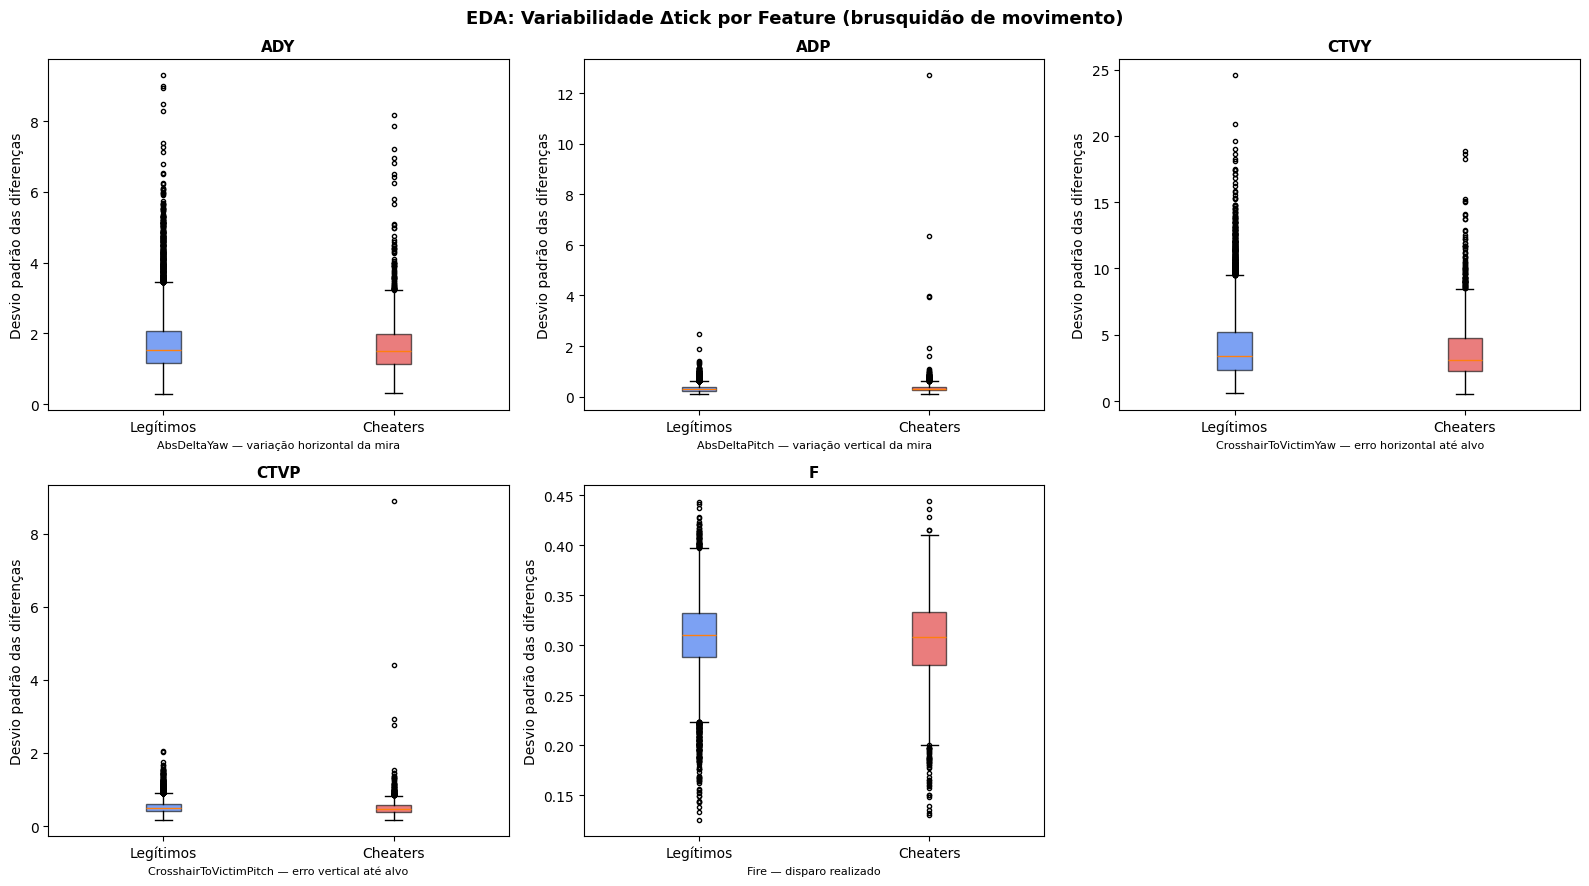

[3c/4] Gerando Figura 4 — Scatter plots por jogador...


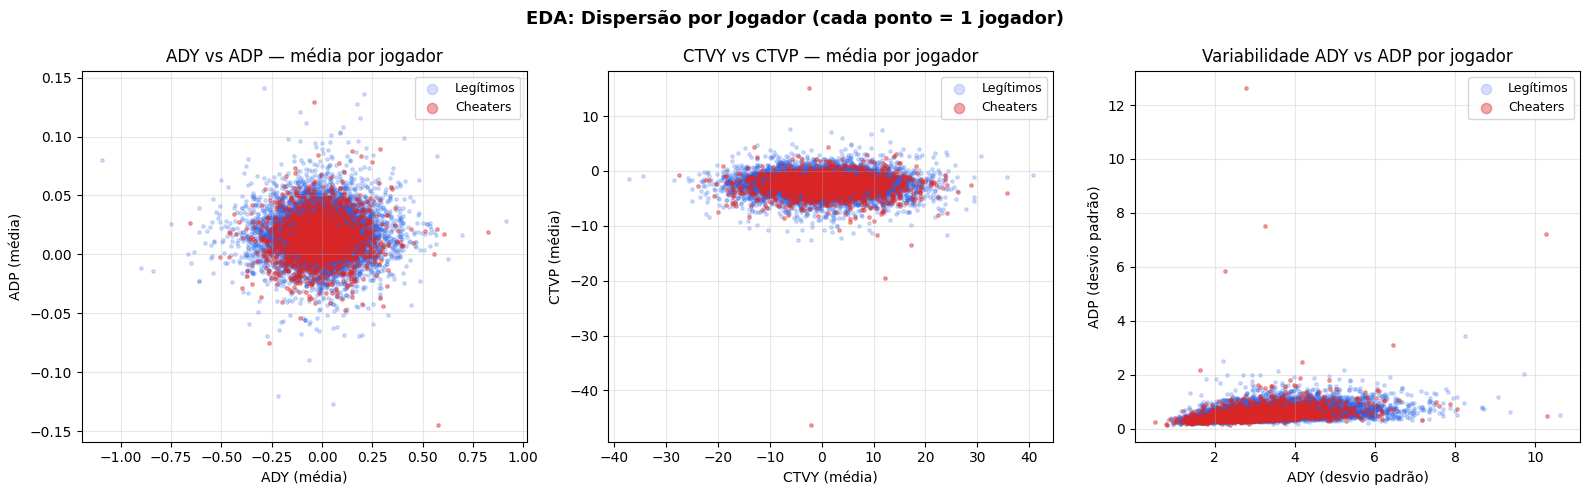

[3d/4] Gerando Figura 5 — Séries temporais médias...


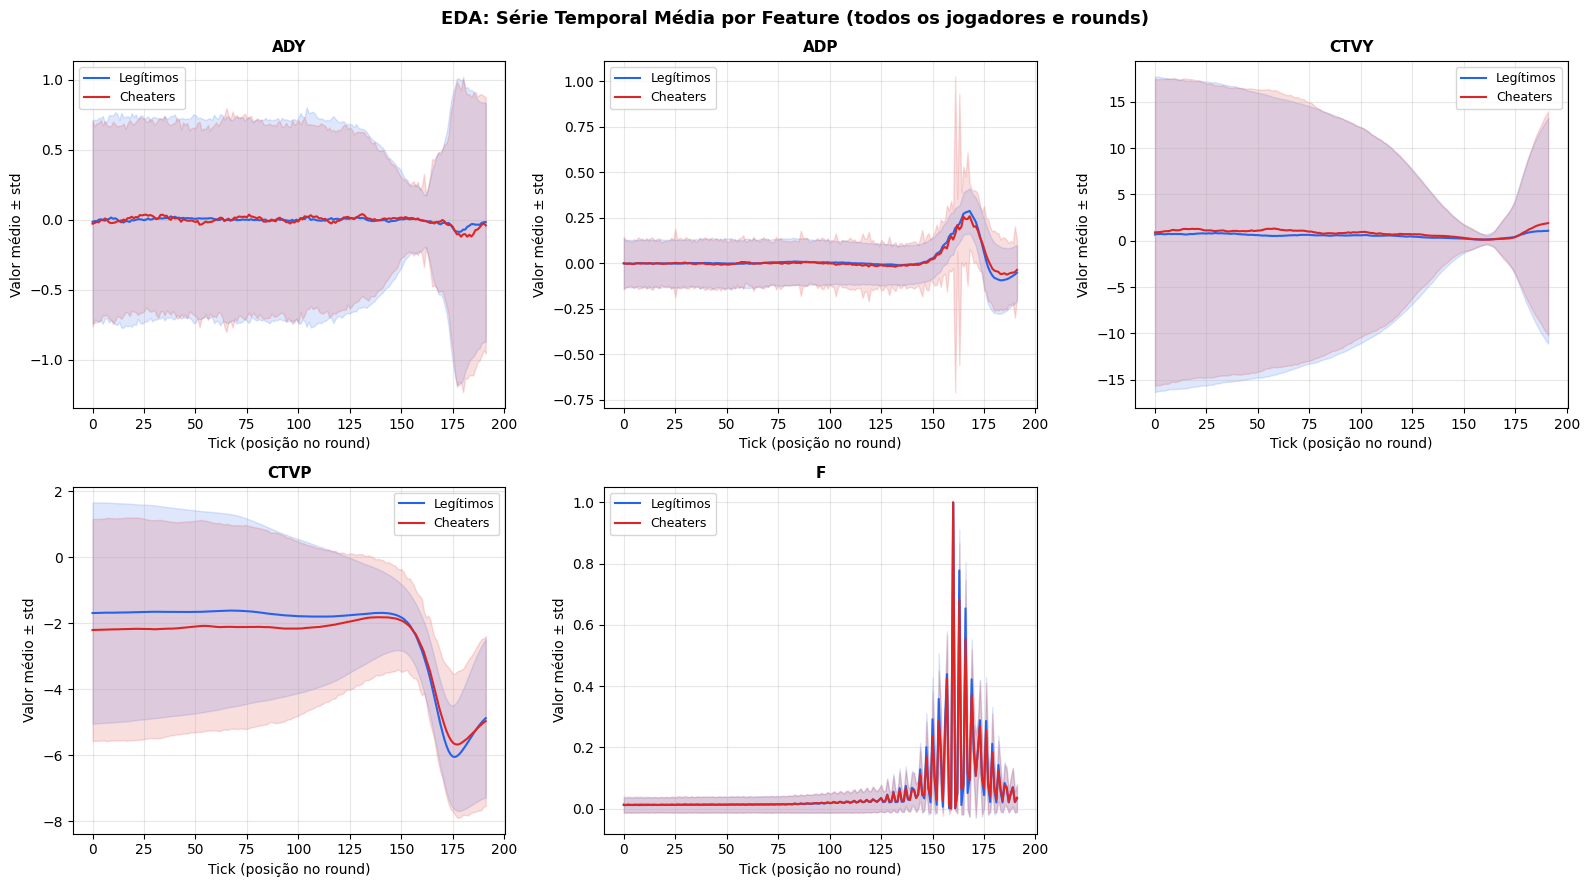


[4/4] Preparando inputs dos algoritmos...
    RF features: 0/12000...
    RF features: 3000/12000...
    RF features: 6000/12000...
    RF features: 9000/12000...
  X_feat (RF):   (12000, 100)  |  151.0s
  X_seq (CNN):   (12000, 1440, 5)  (normalização por fold, dentro da Célula 3)
  X_rnd (LSTM):  (12000, 30, 25)  |  37.8s  (normalização por fold, dentro da Célula 4)

✓ Seção principal concluída. Execute as células 2, 3 e 4 em qualquer ordem.

  Figuras salvas em /content/drive/MyDrive/Cs:Go_Project/resultados:
  01_eda.png            — Visão geral (distribuição, série temporal, correlação)
  eda_02_distribuicoes.png — Histogramas das 5 features (todas as amostras)
  eda_03_variabilidade.png — Variabilidade Δtick das 5 features (brusquidão)
  eda_04_scatter.png       — Dispersão por jogador (ADY/ADP, CTVY/CTVP, std)
  eda_05_series_medias.png — Séries temporais médias com banda de ±1 std


In [ ]:
PROJ_DIR    = '/content/drive/MyDrive/Cs:Go_Project'
RESULTS_DIR = os.path.join(PROJ_DIR, 'resultados')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.chdir(PROJ_DIR)

print(f"Diretório de trabalho: {os.getcwd()}")
print(f"Resultados em:         {RESULTS_DIR}")

# ── Imports ───────────────────────────────────────────────────────────────────
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from scipy import stats
import time, warnings

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score, roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks as K_cb

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

#CARREGAMENTO DOS DADOS
print("\n[1/4] Carregando dados...")

cheaters = np.load('cheaters.npy')   # (2000,  30, 192, 5)
legit    = np.load('legit.npy')      # (10000, 30, 192, 5)

N_ROUNDS = cheaters.shape[1]
N_TICKS  = cheaters.shape[2]
N_FEATS  = cheaters.shape[3]

FEAT_NAMES  = ['ADY', 'ADP', 'CTVY', 'CTVP', 'F']
FEAT_LABELS = [
    'AbsDeltaYaw — variação horizontal da mira',
    'AbsDeltaPitch — variação vertical da mira',
    'CrosshairToVictimYaw — erro horizontal até alvo',
    'CrosshairToVictimPitch — erro vertical até alvo',
    'Fire — disparo realizado',
]

y_cheat = np.ones(len(cheaters),  dtype=np.int8)
y_legit = np.zeros(len(legit),    dtype=np.int8)

X_all = np.concatenate([cheaters, legit], axis=0)    # (12000, 30, 192, 5)
y_all = np.concatenate([y_cheat,  y_legit], axis=0)  # (12000,)

N_CHEATERS   = int(np.sum(y_all == 1))
N_LEGIT      = int(np.sum(y_all == 0))
RATIO        = N_LEGIT / N_CHEATERS
CLASS_WEIGHT = {0: 1.0, 1: RATIO}

print(f"  Total: {len(X_all)} players  |  Cheaters: {N_CHEATERS}  |  Legítimos: {N_LEGIT}")
print(f"  Razão desbalanceamento: 1:{RATIO:.0f}  →  class_weight={CLASS_WEIGHT}")
print(f"  Shape X: {X_all.shape}")

CORES = ['#2563EB', '#DC2626']

# 2. FIGURA 1 — VISÃO GERAL
print("\n[2/4] Gerando Figura 1 — Visão Geral...")

feat_idx = 0  # ADY

fig = plt.figure(figsize=(16, 9))
fig.suptitle("EDA: CS:GO Cheater Detection  (ODS 16)", fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(['Legítimos', 'Cheaters'], [N_LEGIT, N_CHEATERS], color=CORES, width=0.5)
ax1.set_title('Distribuição de classes')
ax1.set_ylabel('Nº de jogadores')
for bar, v in zip(bars, [N_LEGIT, N_CHEATERS]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
             f'{v:,}', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylim(0, N_LEGIT * 1.15)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(cheaters[0, 0, :, feat_idx], label='Cheater #0', color='#DC2626', lw=1.5, alpha=0.85)
ax2.plot(legit[0,    0, :, feat_idx], label='Legítimo #0', color='#2563EB', lw=1.5, alpha=0.85)
ax2.set_title(f'Série temporal — {FEAT_NAMES[feat_idx]}, round 0')
ax2.set_xlabel('Tick'); ax2.set_ylabel('Valor'); ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[0, 2])
flat_c = cheaters[:, :, :, feat_idx].flatten()
flat_l = legit[:,    :, :, feat_idx].flatten()
ax3.hist(flat_l, bins=80, alpha=0.55, label='Legítimos', color='#2563EB', density=True)
ax3.hist(flat_c, bins=80, alpha=0.55, label='Cheaters',  color='#DC2626', density=True)
ax3.set_title(f'Distribuição — {FEAT_NAMES[feat_idx]}')
ax3.set_xlabel('Valor'); ax3.set_ylabel('Densidade'); ax3.legend(fontsize=9)

ax4 = fig.add_subplot(gs[1, 0])
std_diff_c = np.std(np.diff(cheaters[:, :, :, feat_idx], axis=2), axis=2).mean(axis=1)
std_diff_l = np.std(np.diff(legit[:,    :, :, feat_idx], axis=2), axis=2).mean(axis=1)
bp = ax4.boxplot([std_diff_l, std_diff_c], labels=['Legítimos', 'Cheaters'],
                  patch_artist=True, notch=False, sym='.')
for patch, cor in zip(bp['boxes'], CORES):
    patch.set_facecolor(cor); patch.set_alpha(0.6)
ax4.set_title(f'Variabilidade Δtick — {FEAT_NAMES[feat_idx]}')
ax4.set_ylabel('Desvio padrão das diferenças')

ax5 = fig.add_subplot(gs[1, 1])
mean_rounds_c = cheaters[:, :, :, feat_idx].mean(axis=2).mean(axis=0)
mean_rounds_l = legit[:,    :, :, feat_idx].mean(axis=2).mean(axis=0)
ax5.plot(mean_rounds_c, 'o-', label='Cheaters',  color='#DC2626', lw=2, ms=4)
ax5.plot(mean_rounds_l, 's-', label='Legítimos', color='#2563EB', lw=2, ms=4)
ax5.set_title(f'Média de {FEAT_NAMES[feat_idx]} por round')
ax5.set_xlabel('Round'); ax5.set_ylabel('Média'); ax5.legend(fontsize=9)

ax6 = fig.add_subplot(gs[1, 2])
sample_c = cheaters[0].reshape(-1, N_FEATS)
corr = np.corrcoef(sample_c.T)
sns.heatmap(corr, ax=ax6, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            xticklabels=FEAT_NAMES, yticklabels=FEAT_NAMES,
            linewidths=0.4, annot_kws={'size': 9})
ax6.set_title('Correlação features (cheater #0)')

plt.savefig(os.path.join(RESULTS_DIR, '01_eda.png'), dpi=150, bbox_inches='tight')
plt.show()

# 3. FIGURA 2 — DISTRIBUIÇÃO DAS 5 FEATURES
print("[3a/4] Gerando Figura 2 — Distribuições por feature...")

fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9))
fig2.suptitle("EDA: Distribuição de cada Feature — Cheaters vs Legítimos",
              fontsize=13, fontweight='bold')
axes2 = axes2.flatten()

for f in range(N_FEATS):
    ax = axes2[f]
    flat_c = cheaters[:, :, :, f].flatten()
    flat_l = legit[:,    :, :, f].flatten()
    ax.hist(flat_l, bins=80, alpha=0.55, label='Legítimos', color='#2563EB', density=True)
    ax.hist(flat_c, bins=80, alpha=0.55, label='Cheaters',  color='#DC2626', density=True)
    ax.set_title(f'{FEAT_NAMES[f]}', fontsize=11, fontweight='bold')
    ax.set_xlabel(FEAT_LABELS[f], fontsize=8)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=9)

axes2[-1].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_02_distribuicoes.png'), dpi=150, bbox_inches='tight')
plt.show()


# 4. FIGURA 3 — VARIABILIDADE Δtick DAS 5 FEATURES
print("[3b/4] Gerando Figura 3 — Variabilidade por feature...")

fig3, axes3 = plt.subplots(2, 3, figsize=(16, 9))
fig3.suptitle("EDA: Variabilidade Δtick por Feature (brusquidão de movimento)",
              fontsize=13, fontweight='bold')
axes3 = axes3.flatten()

for f in range(N_FEATS):
    ax = axes3[f]
    std_c = np.std(np.diff(cheaters[:, :, :, f], axis=2), axis=2).mean(axis=1)
    std_l = np.std(np.diff(legit[:,    :, :, f], axis=2), axis=2).mean(axis=1)
    bp = ax.boxplot([std_l, std_c], labels=['Legítimos', 'Cheaters'],
                     patch_artist=True, notch=False, sym='.')
    for patch, cor in zip(bp['boxes'], CORES):
        patch.set_facecolor(cor); patch.set_alpha(0.6)
    ax.set_title(f'{FEAT_NAMES[f]}', fontsize=11, fontweight='bold')
    ax.set_xlabel(FEAT_LABELS[f], fontsize=8)
    ax.set_ylabel('Desvio padrão das diferenças')

axes3[-1].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_03_variabilidade.png'), dpi=150, bbox_inches='tight')
plt.show()


# 5. FIGURA 4 — SCATTER PLOTS POR JOGADOR
print("[3c/4] Gerando Figura 4 — Scatter plots por jogador...")

# Média e desvio por jogador (colapsando rounds e ticks)
mean_c = cheaters.mean(axis=(1, 2))
mean_l = legit.mean(axis=(1, 2))
std_c  = cheaters.std(axis=(1, 2))
std_l  = legit.std(axis=(1, 2))

fig4, axes4 = plt.subplots(1, 3, figsize=(16, 5))
fig4.suptitle("EDA: Dispersão por Jogador (cada ponto = 1 jogador)",
              fontsize=13, fontweight='bold')

# ADY vs ADP (médias) — as duas principais features de movimento de mira
ax = axes4[0]
ax.scatter(mean_l[:, 0], mean_l[:, 1], color='#2563EB', alpha=0.2, s=6, label='Legítimos')
ax.scatter(mean_c[:, 0], mean_c[:, 1], color='#DC2626', alpha=0.4, s=6, label='Cheaters')
ax.set_xlabel('ADY (média)'); ax.set_ylabel('ADP (média)')
ax.set_title('ADY vs ADP — média por jogador')
ax.legend(fontsize=9, markerscale=3); ax.grid(alpha=0.3)

# CTVY vs CTVP (médias) — erro de crosshair até a vítima
ax = axes4[1]
ax.scatter(mean_l[:, 2], mean_l[:, 3], color='#2563EB', alpha=0.2, s=6, label='Legítimos')
ax.scatter(mean_c[:, 2], mean_c[:, 3], color='#DC2626', alpha=0.4, s=6, label='Cheaters')
ax.set_xlabel('CTVY (média)'); ax.set_ylabel('CTVP (média)')
ax.set_title('CTVY vs CTVP — média por jogador')
ax.legend(fontsize=9, markerscale=3); ax.grid(alpha=0.3)

# ADY std vs ADP std — variabilidade do movimento de mira por jogador
ax = axes4[2]
ax.scatter(std_l[:, 0], std_l[:, 1], color='#2563EB', alpha=0.2, s=6, label='Legítimos')
ax.scatter(std_c[:, 0], std_c[:, 1], color='#DC2626', alpha=0.4, s=6, label='Cheaters')
ax.set_xlabel('ADY (desvio padrão)'); ax.set_ylabel('ADP (desvio padrão)')
ax.set_title('Variabilidade ADY vs ADP por jogador')
ax.legend(fontsize=9, markerscale=3); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_04_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()


# 6. FIGURA 5 — SÉRIES TEMPORAIS MÉDIAS (todos os jogadores)
print("[3d/4] Gerando Figura 5 — Séries temporais médias...")

mean_tick_c = cheaters.mean(axis=(0, 1))
mean_tick_l = legit.mean(axis=(0, 1))

std_tick_c  = cheaters.mean(axis=1).std(axis=0)
std_tick_l  = legit.mean(axis=1).std(axis=0)

ticks = np.arange(N_TICKS)

fig5, axes5 = plt.subplots(2, 3, figsize=(16, 9))
fig5.suptitle("EDA: Série Temporal Média por Feature (todos os jogadores e rounds)",
              fontsize=13, fontweight='bold')
axes5 = axes5.flatten()

for f in range(N_FEATS):
    ax = axes5[f]
    ax.plot(ticks, mean_tick_l[:, f], color='#2563EB', lw=1.5, label='Legítimos')
    ax.fill_between(ticks,
                    mean_tick_l[:, f] - std_tick_l[:, f],
                    mean_tick_l[:, f] + std_tick_l[:, f],
                    color='#2563EB', alpha=0.15)
    ax.plot(ticks, mean_tick_c[:, f], color='#DC2626', lw=1.5, label='Cheaters')
    ax.fill_between(ticks,
                    mean_tick_c[:, f] - std_tick_c[:, f],
                    mean_tick_c[:, f] + std_tick_c[:, f],
                    color='#DC2626', alpha=0.15)
    ax.set_title(f'{FEAT_NAMES[f]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Tick (posição no round)')
    ax.set_ylabel('Valor médio ± std')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes5[-1].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_05_series_medias.png'), dpi=150, bbox_inches='tight')
plt.show()


# 7. PREPARAÇÃO DOS INPUTS DOS TRÊS ALGORITMOS
print("\n[4/4] Preparando inputs dos algoritmos...")
def extract_statistical_features(X, verbose=False):
    n = len(X)
    rows = []
    for i in range(n):
        if verbose and i % 3000 == 0:
            print(f"    RF features: {i}/{n}...")
        player = X[i]
        flat   = player.reshape(-1, N_FEATS)
        f = []
        for c in range(N_FEATS):
            ch = flat[:, c].astype(np.float64)
            d  = np.diff(ch)
            f += [
                np.mean(ch), np.std(ch), float(np.min(ch)), float(np.max(ch)),
                float(np.median(ch)), float(stats.skew(ch)), float(stats.kurtosis(ch)),
                float(np.percentile(ch, 25)), float(np.percentile(ch, 75)),
                float(np.max(ch) - np.min(ch)),
                float(np.mean(np.abs(d))), float(np.std(d)),
                float(np.max(np.abs(d))), float(np.percentile(np.abs(d), 95)),
                float(np.mean(np.abs(d) > 3 * np.std(ch))),
            ]
        round_means  = player.mean(axis=1)
        round_stds   = player.std(axis=1)
        round_ranges = player.max(axis=1) - player.min(axis=1)
        f += list(round_means.mean(axis=0))
        f += list(round_means.std(axis=0))
        f += list(round_stds.mean(axis=0))
        f += list(round_stds.std(axis=0))
        f += list(round_ranges.mean(axis=0))
        rows.append(f)
    return np.array(rows, dtype=np.float32)

t0 = time.time()
X_feat = extract_statistical_features(X_all, verbose=True)
X_feat = np.nan_to_num(X_feat, nan=0.0, posinf=0.0, neginf=0.0)
print(f"  X_feat (RF):   {X_feat.shape}  |  {time.time()-t0:.1f}s")

SUBSAMPLE = 4
X_seq   = X_all.reshape(len(X_all), N_ROUNDS * N_TICKS, N_FEATS)[:, ::SUBSAMPLE, :].astype(np.float32)
SEQ_LEN = X_seq.shape[1]
print(f"  X_seq (CNN):   {X_seq.shape}  (normalização por fold, dentro da Célula 3)")

def round_level_features(X):
    n    = len(X)
    feat = np.zeros((n, N_ROUNDS, N_FEATS * 5), dtype=np.float32)
    for i in range(n):
        for r in range(N_ROUNDS):
            rd = X[i, r]
            feat[i, r] = np.concatenate([
                rd.mean(axis=0), rd.std(axis=0), rd.max(axis=0),
                rd.min(axis=0),  rd.max(axis=0) - rd.min(axis=0),
            ])
    return feat

t0 = time.time()
X_rnd     = round_level_features(X_all)
RND_FEATS = X_rnd.shape[2]
print(f"  X_rnd (LSTM):  {X_rnd.shape}  |  {time.time()-t0:.1f}s  (normalização por fold, dentro da Célula 4)")

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def get_callbacks():
    return [
        K_cb.EarlyStopping(monitor='val_auc', patience=5,
                            restore_best_weights=True, mode='max'),
        K_cb.ReduceLROnPlateau(monitor='val_auc', patience=3,
                                factor=0.5, min_lr=1e-5, mode='max'),
    ]

print("\n✓ Seção principal concluída. Execute as células 2, 3 e 4 em qualquer ordem.")
print(f"\n  Figuras salvas em {RESULTS_DIR}:")
print("  01_eda.png            — Visão geral (distribuição, série temporal, correlação)")
print("  eda_02_distribuicoes.png — Histogramas das 5 features (todas as amostras)")
print("  eda_03_variabilidade.png — Variabilidade Δtick das 5 features (brusquidão)")
print("  eda_04_scatter.png       — Dispersão por jogador (ADY/ADP, CTVY/CTVP, std)")
print("  eda_05_series_medias.png — Séries temporais médias com banda de ±1 std")

In [ ]:
# CÉLULA 2 — RANDOM FOREST
from sklearn.metrics import precision_recall_curve

print("=" * 55)
print("  ALGORITMO 1: RANDOM FOREST")
print("=" * 55)

def best_threshold(model, X_train, y_train):
    probs       = model.predict_proba(X_train)[:, 1]
    precs, recs, thrs = precision_recall_curve(y_train, probs)
    f1s         = 2 * precs * recs / (precs + recs + 1e-8)
    return float(thrs[np.argmax(f1s[:-1])])

# ── 4.1 Variando n_estimators ─────────────────────────────────────────────────
print("\n4.1 Variando n_estimators (max_depth=None):")
results_nestim = []
for n_est in [50, 100, 200, 300]:
    t0, aucs = time.time(), []
    for tr_idx, te_idx in SKF.split(X_feat, y_all):
        sc  = StandardScaler()
        Xtr = sc.fit_transform(X_feat[tr_idx])
        Xte = sc.transform(X_feat[te_idx])
        rf  = RandomForestClassifier(n_estimators=n_est, max_depth=None,
                                      class_weight='balanced',
                                      random_state=SEED, n_jobs=-1)
        rf.fit(Xtr, y_all[tr_idx])
        aucs.append(roc_auc_score(y_all[te_idx], rf.predict_proba(Xte)[:, 1]))
    elapsed = time.time() - t0
    mu, sd  = np.mean(aucs), np.std(aucs)
    results_nestim.append({'n_estimators': n_est, 'AUC': mu, 'Std': sd, 'Tempo(s)': round(elapsed, 1)})
    print(f"  n_est={n_est:3d} → AUC={mu:.4f}±{sd:.4f}  |  Tempo={elapsed:.1f}s")

# ── 4.2 Variando max_depth ────────────────────────────────────────────────────
print("\n4.2 Variando max_depth (n_estimators=200):")
results_depth = []
for max_d in [5, 10, 20, None]:
    t0, f1s = time.time(), []
    for tr_idx, te_idx in SKF.split(X_feat, y_all):
        sc  = StandardScaler()
        Xtr = sc.fit_transform(X_feat[tr_idx])
        Xte = sc.transform(X_feat[te_idx])
        rf  = RandomForestClassifier(n_estimators=200, max_depth=max_d,
                                      class_weight='balanced',
                                      random_state=SEED, n_jobs=-1)
        rf.fit(Xtr, y_all[tr_idx])
        thr    = best_threshold(rf, Xtr, y_all[tr_idx])
        y_pred = (rf.predict_proba(Xte)[:, 1] > thr).astype(int)
        f1s.append(f1_score(y_all[te_idx], y_pred, zero_division=0))
    elapsed = time.time() - t0
    mu, sd  = np.mean(f1s), np.std(f1s)
    label   = str(max_d) if max_d is not None else 'None'
    results_depth.append({'max_depth': label, 'F1': mu, 'Std': sd, 'Tempo(s)': round(elapsed, 1)})
    print(f"  max_depth={label:5s} → F1={mu:.4f}±{sd:.4f}  |  Tempo={elapsed:.1f}s")

# ── 4.3 Modelo final RF — 5-fold CV ──────────────────────────────────────────
print("\n4.3 Modelo final RF (n_est=200, max_depth=5, 5-fold CV):")
rf_metrics    = {'acc': [], 'f1': [], 'auc': [], 'prec': [], 'rec': [],
                 't_train': [], 't_pred': [], 'threshold': []}
rf_last_preds = {}

for fold, (tr_idx, te_idx) in enumerate(SKF.split(X_feat, y_all)):
    sc  = StandardScaler()
    Xtr = sc.fit_transform(X_feat[tr_idx])
    Xte = sc.transform(X_feat[te_idx])
    rf  = RandomForestClassifier(n_estimators=200, max_depth=15,
                                  min_samples_leaf=10,
                                  class_weight='balanced',
                                  random_state=SEED, n_jobs=-1)
    t0 = time.time(); rf.fit(Xtr, y_all[tr_idx]); t_tr = time.time() - t0

    t0     = time.time()
    thr    = best_threshold(rf, Xtr, y_all[tr_idx])   # calibrado só no treino
    y_prob = rf.predict_proba(Xte)[:, 1]
    y_pred = (y_prob > thr).astype(int)
    t_pr   = time.time() - t0

    rf_metrics['acc'].append(accuracy_score(y_all[te_idx],  y_pred))
    rf_metrics['f1'].append(f1_score(y_all[te_idx],  y_pred, zero_division=0))
    rf_metrics['auc'].append(roc_auc_score(y_all[te_idx], y_prob))
    rf_metrics['prec'].append(precision_score(y_all[te_idx], y_pred, zero_division=0))
    rf_metrics['rec'].append(recall_score(y_all[te_idx],  y_pred, zero_division=0))
    rf_metrics['t_train'].append(t_tr)
    rf_metrics['t_pred'].append(t_pr)
    rf_metrics['threshold'].append(thr)
    rf_last_preds = {'y_true': y_all[te_idx], 'y_pred': y_pred, 'y_prob': y_prob}
    print(f"  Fold {fold+1}: Acc={rf_metrics['acc'][-1]:.4f}  "
          f"F1={rf_metrics['f1'][-1]:.4f}  "
          f"AUC={rf_metrics['auc'][-1]:.4f}  "
          f"thr={thr:.3f}  t_treino={t_tr:.1f}s")

feat_imp = pd.Series(rf.feature_importances_).nlargest(20)

print(f"\n  RF — Média 5-fold:")
print(f"  Acc={np.mean(rf_metrics['acc']):.4f}  "
      f"F1={np.mean(rf_metrics['f1']):.4f}  "
      f"AUC={np.mean(rf_metrics['auc']):.4f}")
print(f"  Threshold médio: {np.mean(rf_metrics['threshold']):.3f}"
      f" ± {np.std(rf_metrics['threshold']):.3f}")
print(f"  Tempo treino total: {sum(rf_metrics['t_train']):.1f}s  "
      f"|  Predição: {sum(rf_metrics['t_pred']):.3f}s")
print("\n" + classification_report(rf_last_preds['y_true'], rf_last_preds['y_pred'],
                                    target_names=['Legítimo', 'Cheater']))
print("✓ Random Forest concluído.")

  ALGORITMO 1: RANDOM FOREST

4.1 Variando n_estimators (max_depth=None):
  n_est= 50 → AUC=0.6829±0.0098  |  Tempo=29.2s
  n_est=100 → AUC=0.6945±0.0097  |  Tempo=47.3s
  n_est=200 → AUC=0.7087±0.0108  |  Tempo=94.4s
  n_est=300 → AUC=0.7127±0.0084  |  Tempo=144.9s

4.2 Variando max_depth (n_estimators=200):
  max_depth=5     → F1=0.3625±0.0131  |  Tempo=36.9s
  max_depth=10    → F1=0.3260±0.0264  |  Tempo=68.5s
  max_depth=20    → F1=0.0416±0.0075  |  Tempo=91.7s
  max_depth=None  → F1=0.0350±0.0097  |  Tempo=92.7s

4.3 Modelo final RF (n_est=200, max_depth=5, 5-fold CV):
  Fold 1: Acc=0.8292  F1=0.3408  AUC=0.7066  thr=0.483  t_treino=14.6s
  Fold 2: Acc=0.8142  F1=0.3201  AUC=0.6956  thr=0.471  t_treino=14.5s
  Fold 3: Acc=0.8258  F1=0.3569  AUC=0.7195  thr=0.476  t_treino=15.2s
  Fold 4: Acc=0.8329  F1=0.3665  AUC=0.7143  thr=0.477  t_treino=15.2s
  Fold 5: Acc=0.8250  F1=0.3312  AUC=0.7095  thr=0.466  t_treino=15.8s

  RF — Média 5-fold:
  Acc=0.8254  F1=0.3431  AUC=0.7091
  Thre

In [ ]:
# ║  CÉLULA 3 — 1D CNN

from sklearn.metrics import precision_recall_curve

print("=" * 55)
print("  ALGORITMO 2: 1D CNN")
print("=" * 55)
print(f"  Input bruto: {X_seq.shape}  (normalização aplicada por fold)")

def normalize_fold(X_train, X_test):
    """Normaliza usando apenas estatísticas do treino, evitando leakage."""
    mu  = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
    Xtr_n = ((X_train - mu) / std).astype(np.float32)
    Xte_n = ((X_test  - mu) / std).astype(np.float32)
    return Xtr_n, Xte_n

def best_threshold_keras(model, X_train, y_train, beta=0.5):
    probs             = model.predict(X_train, verbose=0).flatten()
    precs, recs, thrs = precision_recall_curve(y_train, probs)
    beta2             = beta ** 2
    fbeta = (1 + beta2) * precs * recs / (beta2 * precs + recs + 1e-8)
    return float(thrs[np.argmax(fbeta[:-1])])

def build_cnn(seq_len, n_feats, n_filters=64, n_layers=3, dropout=0.3):
    inp = keras.Input(shape=(seq_len, n_feats), name='input')
    x   = inp
    for i in range(n_layers):
        filt = n_filters * (2 ** min(i, 2))
        x = layers.Conv1D(filt, kernel_size=7, padding='same',
                           activation='relu', name=f'conv{i+1}')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(pool_size=4, name=f'pool{i+1}')(x)
        x = layers.Dropout(dropout)(x)

    # ALTERAÇÃO: dois poolings concatenados em vez de só GAP
    gap = layers.GlobalAveragePooling1D(name='gap')(x)
    gmp = layers.GlobalMaxPooling1D(name='gmp')(x)
    x   = layers.Concatenate(name='pool_concat')([gap, gmp])

    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    m   = keras.Model(inp, out, name=f'CNN_f{n_filters}_l{n_layers}')
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=[keras.metrics.AUC(name='auc')])
    return m

# ── 5.1 Variando n_filters ────────────────────────────────────────────────────
print("\n5.1 Variando n_filters (3 layers, 1 fold):")
tr0, te0 = list(SKF.split(X_seq, y_all))[0]
Xtr0_n, Xte0_n = normalize_fold(X_seq[tr0], X_seq[te0])
results_filters = []
for n_filt in [32, 64, 128]:
    cnn = build_cnn(SEQ_LEN, N_FEATS, n_filters=n_filt)
    t0  = time.time()
    cnn.fit(Xtr0_n, y_all[tr0],
            validation_data=(Xte0_n, y_all[te0]),
            epochs=15, batch_size=64,
            class_weight=CLASS_WEIGHT,
            callbacks=get_callbacks(),
            verbose=0)
    elapsed = time.time() - t0
    yp    = cnn.predict(Xte0_n, verbose=0).flatten()
    yc    = (yp > 0.5).astype(int)
    auc_v = roc_auc_score(y_all[te0], yp)
    f1_v  = f1_score(y_all[te0], yc, zero_division=0)
    results_filters.append({'n_filters': n_filt, 'AUC': auc_v, 'F1': f1_v, 'Tempo(s)': round(elapsed, 1)})
    print(f"  n_filters={n_filt:3d} → AUC={auc_v:.4f}  F1={f1_v:.4f}  Tempo={elapsed:.1f}s")

# ── 5.2 Variando n_layers ─────────────────────────────────────────────────────
print("\n5.2 Variando n_layers (n_filters=64, 1 fold):")
results_layers = []
for n_lay in [2, 3, 4]:
    cnn = build_cnn(SEQ_LEN, N_FEATS, n_filters=64, n_layers=n_lay)
    t0  = time.time()
    cnn.fit(Xtr0_n, y_all[tr0],
            validation_data=(Xte0_n, y_all[te0]),
            epochs=15, batch_size=64,
            class_weight=CLASS_WEIGHT,
            callbacks=get_callbacks(),
            verbose=0)
    elapsed = time.time() - t0
    yp    = cnn.predict(Xte0_n, verbose=0).flatten()
    yc    = (yp > 0.5).astype(int)
    auc_v = roc_auc_score(y_all[te0], yp)
    f1_v  = f1_score(y_all[te0], yc, zero_division=0)
    results_layers.append({'n_layers': n_lay, 'AUC': auc_v, 'F1': f1_v, 'Tempo(s)': round(elapsed, 1)})
    print(f"  n_layers={n_lay} → AUC={auc_v:.4f}  F1={f1_v:.4f}  Tempo={elapsed:.1f}s")

# ── 5.3 Modelo final CNN — 5-fold CV ─────────────────────────────────────────
print("\n5.3 Modelo final CNN (n_filters=64, n_layers=3, 5-fold CV):")
cnn_metrics    = {'acc': [], 'f1': [], 'auc': [], 'prec': [], 'rec': [],
                  't_train': [], 't_pred': [], 'threshold': []}
cnn_last_preds = {}

for fold, (tr_idx, te_idx) in enumerate(SKF.split(X_seq, y_all)):
    Xtr_n, Xte_n = normalize_fold(X_seq[tr_idx], X_seq[te_idx])
    cnn = build_cnn(SEQ_LEN, N_FEATS, n_filters=64, n_layers=3)
    t0  = time.time()
    cnn.fit(Xtr_n, y_all[tr_idx],
            validation_data=(Xte_n, y_all[te_idx]),
            epochs=25, batch_size=64,
            class_weight=CLASS_WEIGHT,
            callbacks=get_callbacks(),
            verbose=0)
    t_tr = time.time() - t0

    t0     = time.time()
    thr    = best_threshold_keras(cnn, Xtr_n, y_all[tr_idx])  # calibrado só no treino
    y_prob = cnn.predict(Xte_n, verbose=0).flatten()
    y_pred = (y_prob > thr).astype(int)
    t_pr   = time.time() - t0

    cnn_metrics['acc'].append(accuracy_score(y_all[te_idx], y_pred))
    cnn_metrics['f1'].append(f1_score(y_all[te_idx],  y_pred, zero_division=0))
    cnn_metrics['auc'].append(roc_auc_score(y_all[te_idx], y_prob))
    cnn_metrics['prec'].append(precision_score(y_all[te_idx], y_pred, zero_division=0))
    cnn_metrics['rec'].append(recall_score(y_all[te_idx],  y_pred, zero_division=0))
    cnn_metrics['t_train'].append(t_tr)
    cnn_metrics['t_pred'].append(t_pr)
    cnn_metrics['threshold'].append(thr)
    cnn_last_preds = {'y_true': y_all[te_idx], 'y_pred': y_pred, 'y_prob': y_prob}
    print(f"  Fold {fold+1}: Acc={cnn_metrics['acc'][-1]:.4f}  "
          f"F1={cnn_metrics['f1'][-1]:.4f}  "
          f"AUC={cnn_metrics['auc'][-1]:.4f}  "
          f"thr={thr:.3f}  t_treino={t_tr:.1f}s")

print(f"\n  CNN — Média 5-fold:")
print(f"  Acc={np.mean(cnn_metrics['acc']):.4f}  "
      f"F1={np.mean(cnn_metrics['f1']):.4f}  "
      f"AUC={np.mean(cnn_metrics['auc']):.4f}")
print(f"  Threshold médio: {np.mean(cnn_metrics['threshold']):.3f}"
      f" ± {np.std(cnn_metrics['threshold']):.3f}")
print(f"  Tempo treino total: {sum(cnn_metrics['t_train']):.1f}s  "
      f"|  Predição: {sum(cnn_metrics['t_pred']):.3f}s")
print("\n" + classification_report(cnn_last_preds['y_true'], cnn_last_preds['y_pred'],
                                    target_names=['Legítimo', 'Cheater']))
print("✓ CNN concluída.")

  ALGORITMO 2: 1D CNN
  Input bruto: (12000, 1440, 5)  (normalização aplicada por fold)

5.1 Variando n_filters (3 layers, 1 fold):
  n_filters= 32 → AUC=0.7984  F1=0.3437  Tempo=47.7s
  n_filters= 64 → AUC=0.7917  F1=0.4722  Tempo=62.4s
  n_filters=128 → AUC=0.8129  F1=0.5499  Tempo=96.9s

5.2 Variando n_layers (n_filters=64, 1 fold):
  n_layers=2 → AUC=0.7354  F1=0.4680  Tempo=50.8s
  n_layers=3 → AUC=0.8135  F1=0.4503  Tempo=58.2s
  n_layers=4 → AUC=0.8220  F1=0.4234  Tempo=63.4s

5.3 Modelo final CNN (n_filters=64, n_layers=3, 5-fold CV):
  Fold 1: Acc=0.8796  F1=0.5463  AUC=0.8315  thr=0.922  t_treino=90.5s
  Fold 2: Acc=0.8662  F1=0.5008  AUC=0.8140  thr=0.845  t_treino=79.5s
  Fold 3: Acc=0.8767  F1=0.5210  AUC=0.8296  thr=0.872  t_treino=89.9s
  Fold 4: Acc=0.8717  F1=0.4984  AUC=0.7981  thr=0.808  t_treino=89.2s
  Fold 5: Acc=0.8617  F1=0.4877  AUC=0.8005  thr=0.895  t_treino=85.4s

  CNN — Média 5-fold:
  Acc=0.8712  F1=0.5108  AUC=0.8147
  Threshold médio: 0.868 ± 0.039
  Te

In [ ]:
#  CÉLULA 4 — LSTM

from sklearn.metrics import precision_recall_curve

print(f"  Input bruto: {X_rnd.shape}  (normalização aplicada por fold)")

def normalize_fold(X_train, X_test):
    mu  = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
    Xtr_n = ((X_train - mu) / std).astype(np.float32)
    Xte_n = ((X_test  - mu) / std).astype(np.float32)
    return Xtr_n, Xte_n

def best_threshold_keras(model, X_train, y_train, beta=0.5):
    probs             = model.predict(X_train, verbose=0).flatten()
    precs, recs, thrs = precision_recall_curve(y_train, probs)
    beta2             = beta ** 2
    fbeta = (1 + beta2) * precs * recs / (beta2 * precs + recs + 1e-8)
    return float(thrs[np.argmax(fbeta[:-1])])

def build_lstm(n_rounds=30, n_feats=25, units=64, dropout=0.3):
    inp = keras.Input(shape=(n_rounds, n_feats), name='input')
    x   = layers.Bidirectional(layers.LSTM(units, return_sequences=True,
                                            name='lstm1'))(inp)
    x   = layers.Dropout(dropout)(x)
    x   = layers.Bidirectional(layers.LSTM(units // 2, name='lstm2'))(x)
    x   = layers.Dropout(dropout)(x)
    x   = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    m   = keras.Model(inp, out, name=f'LSTM_u{units}')
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=[keras.metrics.AUC(name='auc')])
    return m

# ── 6.1 Variando units ───────────────────────────────────────────────────────
print("\n6.1 Variando units (1 fold):")
tr0_l, te0_l = list(SKF.split(X_rnd, y_all))[0]
Xtr0_n, Xte0_n = normalize_fold(X_rnd[tr0_l], X_rnd[te0_l])
results_units = []
for units in [32, 64, 128]:
    lstm = build_lstm(n_rounds=N_ROUNDS, n_feats=RND_FEATS, units=units)
    t0   = time.time()
    lstm.fit(Xtr0_n, y_all[tr0_l],
             validation_data=(Xte0_n, y_all[te0_l]),
             epochs=20, batch_size=64,
             class_weight=CLASS_WEIGHT,
             callbacks=get_callbacks(),
             verbose=0)
    elapsed = time.time() - t0
    yp    = lstm.predict(Xte0_n, verbose=0).flatten()
    yc    = (yp > 0.5).astype(int)
    auc_v = roc_auc_score(y_all[te0_l], yp)
    f1_v  = f1_score(y_all[te0_l], yc, zero_division=0)
    results_units.append({'units': units, 'AUC': auc_v, 'F1': f1_v, 'Tempo(s)': round(elapsed, 1)})
    print(f"  units={units:3d} → AUC={auc_v:.4f}  F1={f1_v:.4f}  Tempo={elapsed:.1f}s")

# ── 6.2 Modelo final LSTM — 5-fold CV ────────────────────────────────────────
print("\n6.2 Modelo final LSTM (units=64, 5-fold CV):")
lstm_metrics    = {'acc': [], 'f1': [], 'auc': [], 'prec': [], 'rec': [],
                   't_train': [], 't_pred': [], 'threshold': []}
lstm_last_preds = {}

for fold, (tr_idx, te_idx) in enumerate(SKF.split(X_rnd, y_all)):
    Xtr_n, Xte_n = normalize_fold(X_rnd[tr_idx], X_rnd[te_idx])
    lstm = build_lstm(n_rounds=N_ROUNDS, n_feats=RND_FEATS, units=64)
    t0   = time.time()
    lstm.fit(Xtr_n, y_all[tr_idx],
             validation_data=(Xte_n, y_all[te_idx]),
             epochs=30, batch_size=64,
             class_weight=CLASS_WEIGHT,
             callbacks=get_callbacks(),
             verbose=0)
    t_tr = time.time() - t0

    t0     = time.time()
    thr    = best_threshold_keras(lstm, Xtr_n, y_all[tr_idx])  # calibrado só no treino
    y_prob = lstm.predict(Xte_n, verbose=0).flatten()
    y_pred = (y_prob > thr).astype(int)
    t_pr   = time.time() - t0

    lstm_metrics['acc'].append(accuracy_score(y_all[te_idx], y_pred))
    lstm_metrics['f1'].append(f1_score(y_all[te_idx],  y_pred, zero_division=0))
    lstm_metrics['auc'].append(roc_auc_score(y_all[te_idx], y_prob))
    lstm_metrics['prec'].append(precision_score(y_all[te_idx], y_pred, zero_division=0))
    lstm_metrics['rec'].append(recall_score(y_all[te_idx],  y_pred, zero_division=0))
    lstm_metrics['t_train'].append(t_tr)
    lstm_metrics['t_pred'].append(t_pr)
    lstm_metrics['threshold'].append(thr)
    lstm_last_preds = {'y_true': y_all[te_idx], 'y_pred': y_pred, 'y_prob': y_prob}
    print(f"  Fold {fold+1}: Acc={lstm_metrics['acc'][-1]:.4f}  "
          f"F1={lstm_metrics['f1'][-1]:.4f}  "
          f"AUC={lstm_metrics['auc'][-1]:.4f}  "
          f"thr={thr:.3f}  t_treino={t_tr:.1f}s")

print(f"\n  LSTM — Média 5-fold:")
print(f"  Acc={np.mean(lstm_metrics['acc']):.4f}  "
      f"F1={np.mean(lstm_metrics['f1']):.4f}  "
      f"AUC={np.mean(lstm_metrics['auc']):.4f}")
print(f"  Threshold médio: {np.mean(lstm_metrics['threshold']):.3f}"
      f" ± {np.std(lstm_metrics['threshold']):.3f}")
print(f"  Tempo treino total: {sum(lstm_metrics['t_train']):.1f}s  "
      f"|  Predição: {sum(lstm_metrics['t_pred']):.3f}s")
print("\n" + classification_report(lstm_last_preds['y_true'], lstm_last_preds['y_pred'],
                                    target_names=['Legítimo', 'Cheater']))
print("✓ LSTM concluído.")

  ALGORITMO 3: LSTM (BÔNUS)
  Input bruto: (12000, 30, 25)  (normalização aplicada por fold)

6.1 Variando units (1 fold):
  units= 32 → AUC=0.6607  F1=0.3575  Tempo=31.5s
  units= 64 → AUC=0.6464  F1=0.3195  Tempo=28.5s
  units=128 → AUC=0.6407  F1=0.3381  Tempo=19.9s

6.2 Modelo final LSTM (units=64, 5-fold CV):
  Fold 1: Acc=0.8087  F1=0.2537  AUC=0.6589  thr=0.735  t_treino=28.0s
  Fold 2: Acc=0.8008  F1=0.2555  AUC=0.6411  thr=0.742  t_treino=21.2s
  Fold 3: Acc=0.8021  F1=0.3224  AUC=0.6737  thr=0.694  t_treino=26.0s
  Fold 4: Acc=0.8142  F1=0.3096  AUC=0.6713  thr=0.777  t_treino=26.5s
  Fold 5: Acc=0.8033  F1=0.2892  AUC=0.6672  thr=0.726  t_treino=30.4s

  LSTM — Média 5-fold:
  Acc=0.8058  F1=0.2861  AUC=0.6625
  Threshold médio: 0.735 ± 0.027
  Tempo treino total: 132.0s  |  Predição: 11.840s

              precision    recall  f1-score   support

    Legítimo       0.86      0.92      0.89      2000
     Cheater       0.36      0.24      0.29       400

    accuracy        

[Plots] Gerando visualizações de comparação...


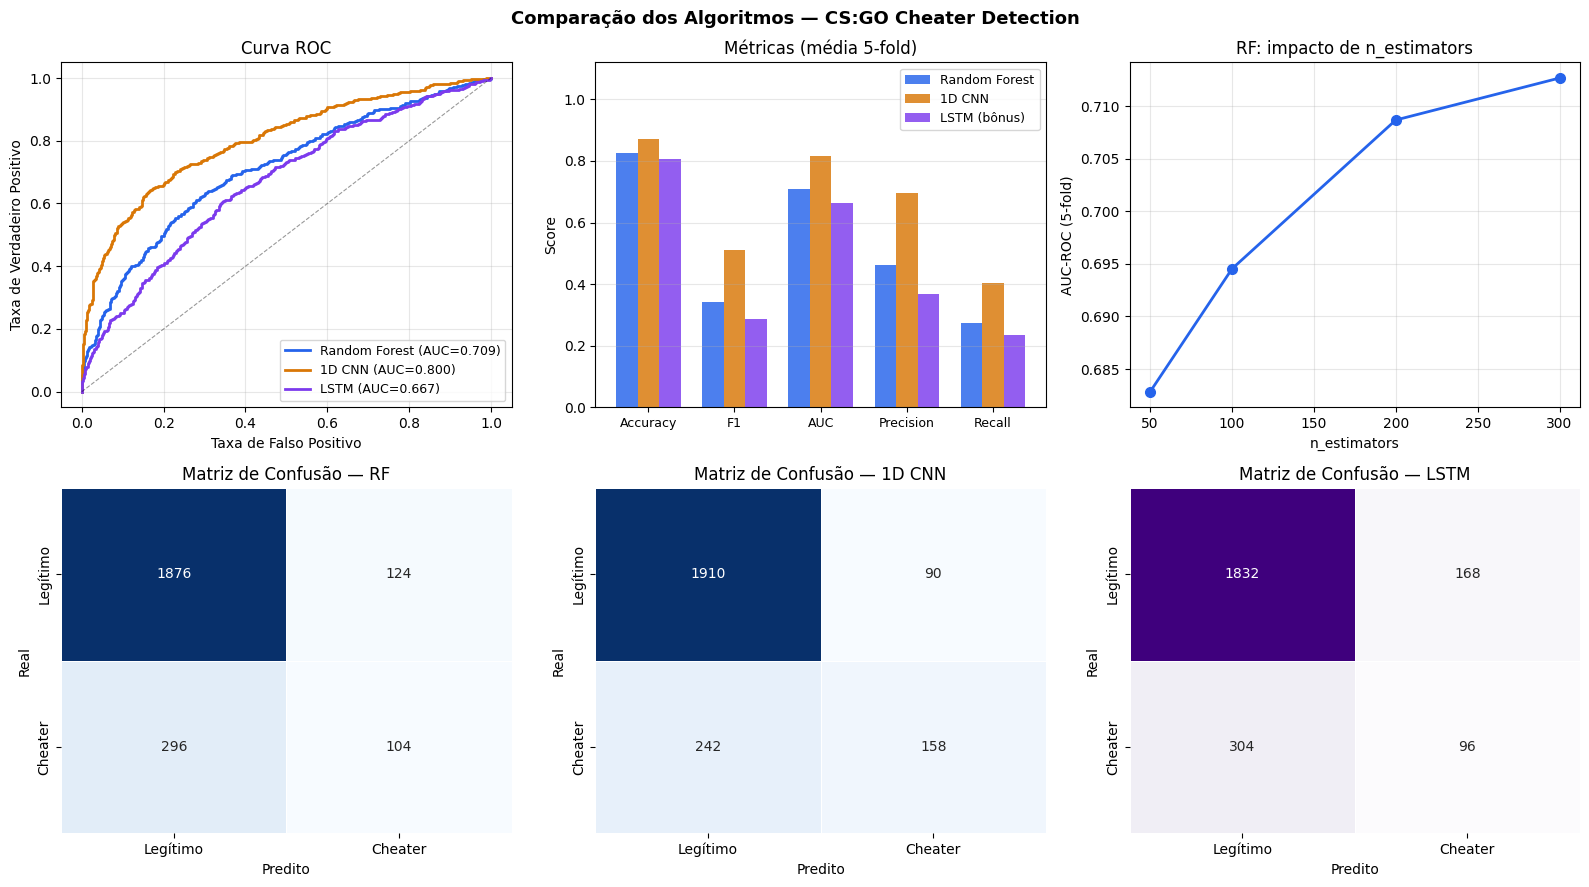

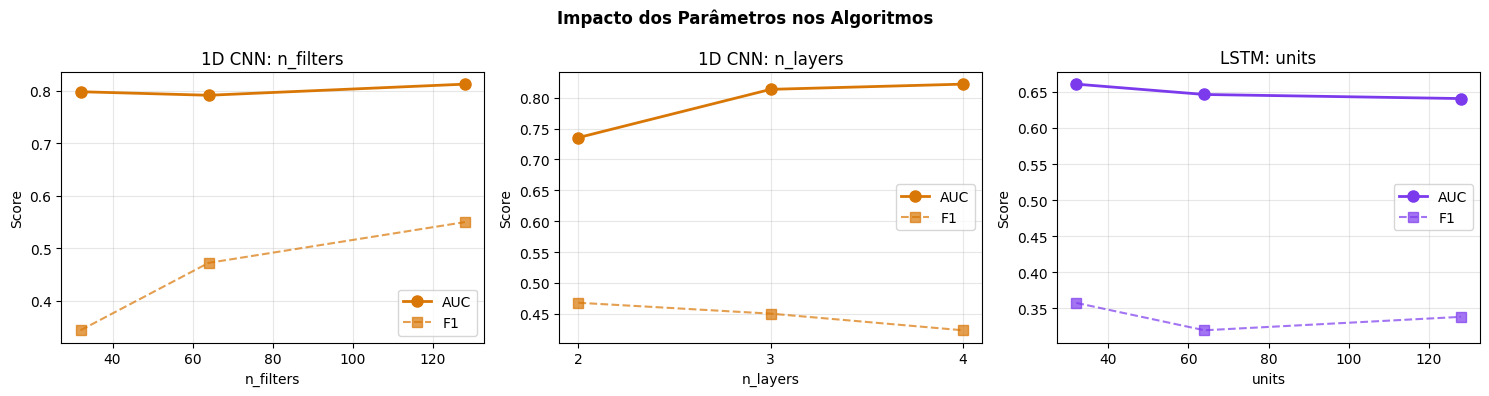

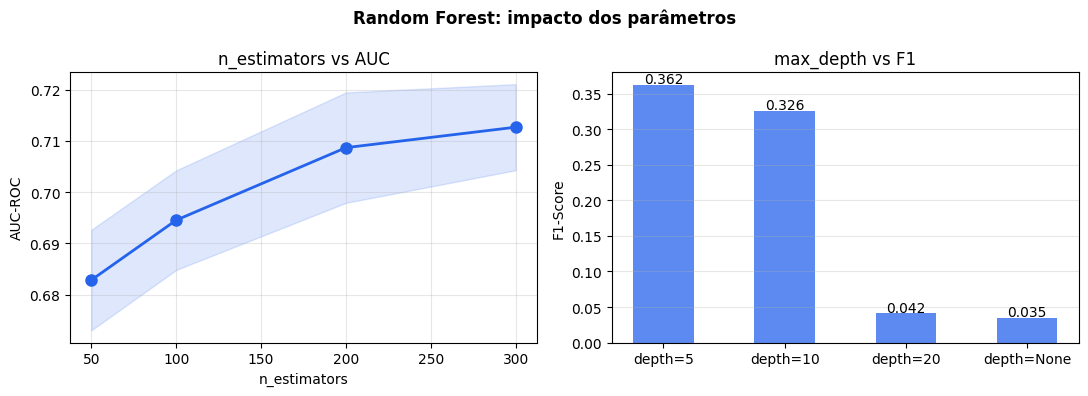

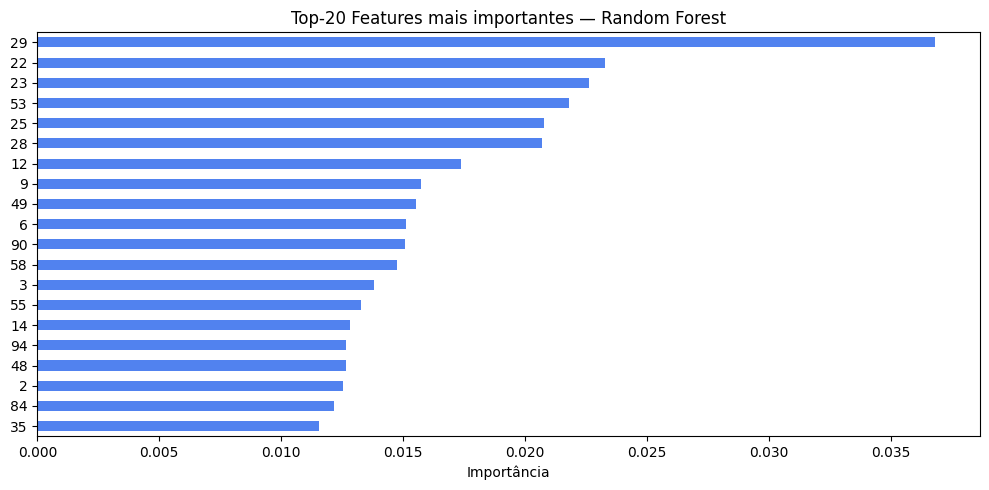


  RESUMO FINAL — COMPARAÇÃO DOS ALGORITMOS
    Algoritmo      Accuracy      F1-Score       AUC-ROC Precision Recall T.Treino(s) T.Pred(s)
Random Forest 0.8254±0.0063 0.3431±0.0168 0.7091±0.0080    0.4611 0.2735        75.3     1.635
       1D CNN 0.8712±0.0066 0.5108±0.0208 0.8147±0.0140    0.6975 0.4035       434.4    13.593
 LSTM (bônus) 0.8058±0.0050 0.2861±0.0278 0.6625±0.0118    0.3694 0.2345       132.0    11.840

  Todos os arquivos salvos em: /content/drive/MyDrive/Cs:Go_Project/resultados


In [ ]:
# ║  CÉLULA 5 — COMPARAÇÃO FINAL

ALGOS = ['Random Forest', '1D CNN', 'LSTM (bônus)']
CORES = ['#2563EB', '#D97706', '#7C3AED']

M = {
    'Random Forest': rf_metrics,
    '1D CNN':        cnn_metrics,
    'LSTM (bônus)':  lstm_metrics,
}

print("[Plots] Gerando visualizações de comparação...")

# ── Figura 2: Visão geral ─────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9))
fig2.suptitle("Comparação dos Algoritmos — CS:GO Cheater Detection",
              fontsize=13, fontweight='bold')

ax = axes2[0, 0]
for preds, nome, cor in [
    (rf_last_preds,   'Random Forest', CORES[0]),
    (cnn_last_preds,  '1D CNN',        CORES[1]),
    (lstm_last_preds, 'LSTM',  CORES[2]),
]:
    fpr, tpr, _ = roc_curve(preds['y_true'], preds['y_prob'])
    auc_v = roc_auc_score(preds['y_true'], preds['y_prob'])
    ax.plot(fpr, tpr, color=cor, lw=2, label=f'{nome} (AUC={auc_v:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4)
ax.set_xlabel('Taxa de Falso Positivo')
ax.set_ylabel('Taxa de Verdadeiro Positivo')
ax.set_title('Curva ROC'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes2[0, 1]
metricas  = ['acc', 'f1', 'auc', 'prec', 'rec']
met_nomes = ['Accuracy', 'F1', 'AUC', 'Precision', 'Recall']
x, w = np.arange(len(met_nomes)), 0.25
for i, (nome, cor) in enumerate(zip(ALGOS, CORES)):
    vals = [np.mean(M[nome][m]) for m in metricas]
    ax.bar(x + i * w, vals, w, label=nome, color=cor, alpha=0.82)
ax.set_xticks(x + w); ax.set_xticklabels(met_nomes, fontsize=9)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Métricas (média 5-fold)')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

ax = axes2[0, 2]
df_ne = pd.DataFrame(results_nestim)
ax.errorbar(df_ne['n_estimators'], df_ne['AUC'], fmt='o-',
            color=CORES[0], lw=2, ms=7, capsize=4)
ax.set_xlabel('n_estimators'); ax.set_ylabel('AUC-ROC (5-fold)')
ax.set_title('RF: impacto de n_estimators'); ax.grid(alpha=0.3)

for ax_idx, (preds, nome, cmap) in enumerate([
    (rf_last_preds,   'RF',     'Blues'),
    (cnn_last_preds,  '1D CNN', 'Blues'),
    (lstm_last_preds, 'LSTM',   'Purples'),
]):
    ax = axes2[1, ax_idx]
    cm = confusion_matrix(preds['y_true'], preds['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Legítimo', 'Cheater'],
                yticklabels=['Legítimo', 'Cheater'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'Matriz de Confusão — {nome}')
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_comparacao.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figura 3: Impacto dos parâmetros CNN e LSTM ───────────────────────────────
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 4))
fig3.suptitle("Impacto dos Parâmetros nos Algoritmos", fontsize=12, fontweight='bold')

ax = axes3[0]
df_f = pd.DataFrame(results_filters)
ax.plot(df_f['n_filters'], df_f['AUC'], 'o-', color=CORES[1], lw=2, ms=8, label='AUC')
ax.plot(df_f['n_filters'], df_f['F1'],  's--', color=CORES[1], lw=1.5, ms=7, alpha=0.7, label='F1')
ax.set_xlabel('n_filters'); ax.set_ylabel('Score')
ax.set_title('1D CNN: n_filters'); ax.legend(); ax.grid(alpha=0.3)

ax = axes3[1]
df_l = pd.DataFrame(results_layers)
ax.plot(df_l['n_layers'], df_l['AUC'], 'o-', color=CORES[1], lw=2, ms=8, label='AUC')
ax.plot(df_l['n_layers'], df_l['F1'],  's--', color=CORES[1], lw=1.5, ms=7, alpha=0.7, label='F1')
ax.set_xlabel('n_layers'); ax.set_ylabel('Score')
ax.set_title('1D CNN: n_layers'); ax.legend(); ax.grid(alpha=0.3); ax.set_xticks([2, 3, 4])

ax = axes3[2]
df_u = pd.DataFrame(results_units)
ax.plot(df_u['units'], df_u['AUC'], 'o-', color=CORES[2], lw=2, ms=8, label='AUC')
ax.plot(df_u['units'], df_u['F1'],  's--', color=CORES[2], lw=1.5, ms=7, alpha=0.7, label='F1')
ax.set_xlabel('units'); ax.set_ylabel('Score')
ax.set_title('LSTM: units'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_parametros.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figura 4: Parâmetros do RF ────────────────────────────────────────────────
fig4, axes4 = plt.subplots(1, 2, figsize=(11, 4))
fig4.suptitle("Random Forest: impacto dos parâmetros", fontsize=12, fontweight='bold')

ax = axes4[0]
ax.plot(df_ne['n_estimators'], df_ne['AUC'], 'o-', color=CORES[0], lw=2, ms=8)
ax.fill_between(df_ne['n_estimators'],
                df_ne['AUC'] - df_ne['Std'],
                df_ne['AUC'] + df_ne['Std'],
                color=CORES[0], alpha=0.15)
ax.set_xlabel('n_estimators'); ax.set_ylabel('AUC-ROC')
ax.set_title('n_estimators vs AUC'); ax.grid(alpha=0.3)

ax   = axes4[1]
df_d  = pd.DataFrame(results_depth)
x_pos = range(len(df_d))
bars  = ax.bar(x_pos, df_d['F1'], color=CORES[0], alpha=0.75, width=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'depth={d}' for d in df_d['max_depth']])
ax.set_ylabel('F1-Score'); ax.set_title('max_depth vs F1'); ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, df_d['F1']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '04_rf_parametros.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figura 5: Feature importance ──────────────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(10, 5))
feat_imp.sort_values().plot(kind='barh', ax=ax5, color=CORES[0], alpha=0.8)
ax5.set_title('Top-20 Features mais importantes — Random Forest', fontsize=12)
ax5.set_xlabel('Importância')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '05_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Tabela resumo final ───────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  RESUMO FINAL — COMPARAÇÃO DOS ALGORITMOS")
print("=" * 60)

summary = pd.DataFrame({
    'Algoritmo':    ALGOS,
    'Accuracy':     [f"{np.mean(M[a]['acc']):.4f}±{np.std(M[a]['acc']):.4f}"  for a in ALGOS],
    'F1-Score':     [f"{np.mean(M[a]['f1']):.4f}±{np.std(M[a]['f1']):.4f}"   for a in ALGOS],
    'AUC-ROC':      [f"{np.mean(M[a]['auc']):.4f}±{np.std(M[a]['auc']):.4f}" for a in ALGOS],
    'Precision':    [f"{np.mean(M[a]['prec']):.4f}"                            for a in ALGOS],
    'Recall':       [f"{np.mean(M[a]['rec']):.4f}"                             for a in ALGOS],
    'T.Treino(s)':  [f"{sum(M[a]['t_train']):.1f}"                             for a in ALGOS],
    'T.Pred(s)':    [f"{sum(M[a]['t_pred']):.3f}"                              for a in ALGOS],
})
print(summary.to_string(index=False))
summary.to_csv(os.path.join(RESULTS_DIR, 'resumo_final.csv'), index=False)
print(f"\n  Todos os arquivos salvos em: {RESULTS_DIR}")
print("=" * 60)